# **Part 2: Image filtering with Low-pass and High-pass Filter**

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

from src.config.config import FILTER_IMAGE_PATH

## **Function to display images**

In [2]:
def show_plt(title, img):
    plt.title(title)
    plt.axis("off")

    if img.ndim == 2:
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    else:
        rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(rgb_img)

## **Load an input color image**

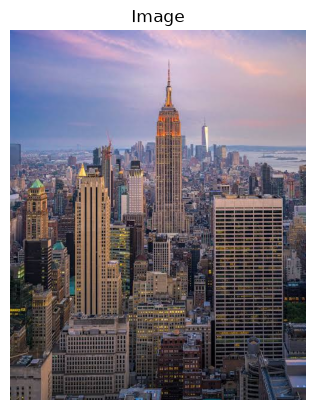

In [3]:
img = cv2.imread(str(FILTER_IMAGE_PATH), cv2.IMREAD_COLOR)
show_plt("Image", img)

## **Convert color image to grayscale**

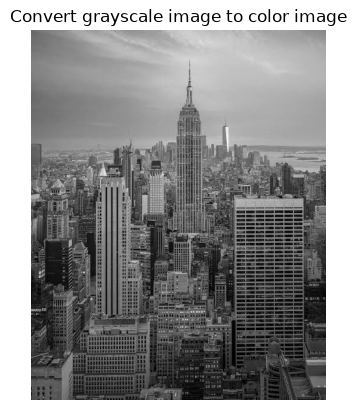

In [4]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show_plt("Convert grayscale image to color image", gray_img)

## **Low-Pass Filters**

### *Mean Filter*

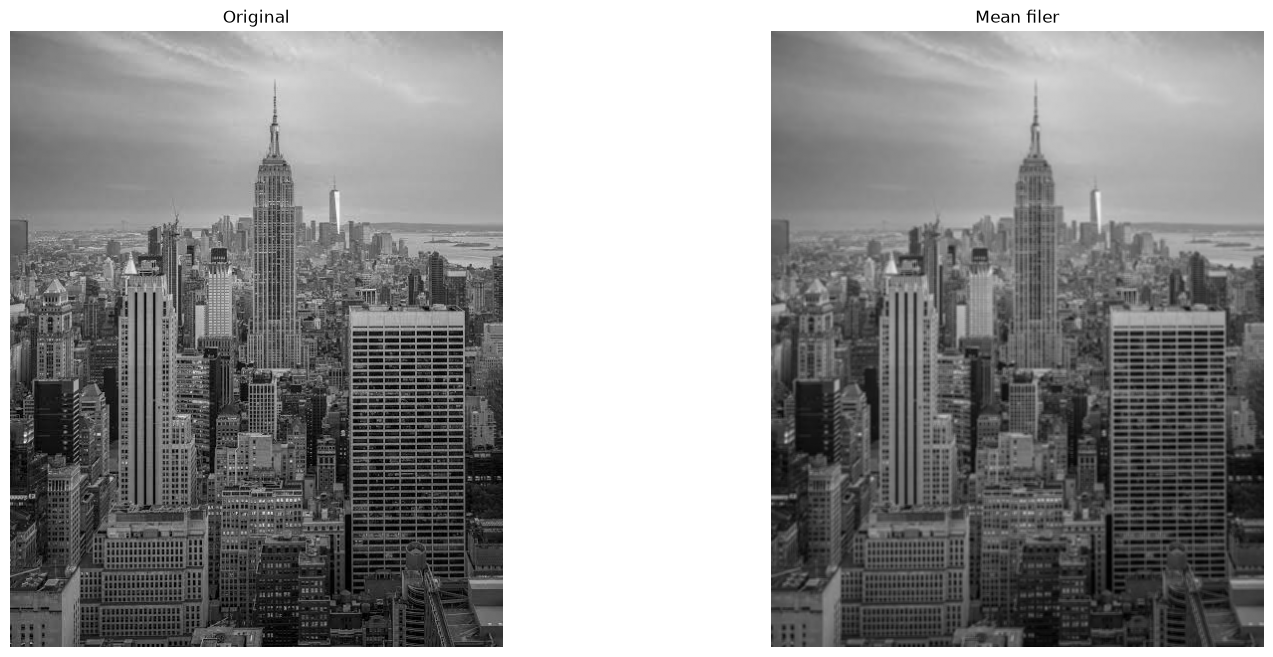

In [5]:
# Kernel
kernel_size = 3
kernel = np.ones((kernel_size, kernel_size), np.float32)/(kernel_size**2)

# Convolution
img_mean = cv2.filter2D(gray_img, -1, kernel)

plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
show_plt("Original", gray_img)
plt.subplot(1,2,2)
show_plt("Mean filer", img_mean)

### *Median Fitler*

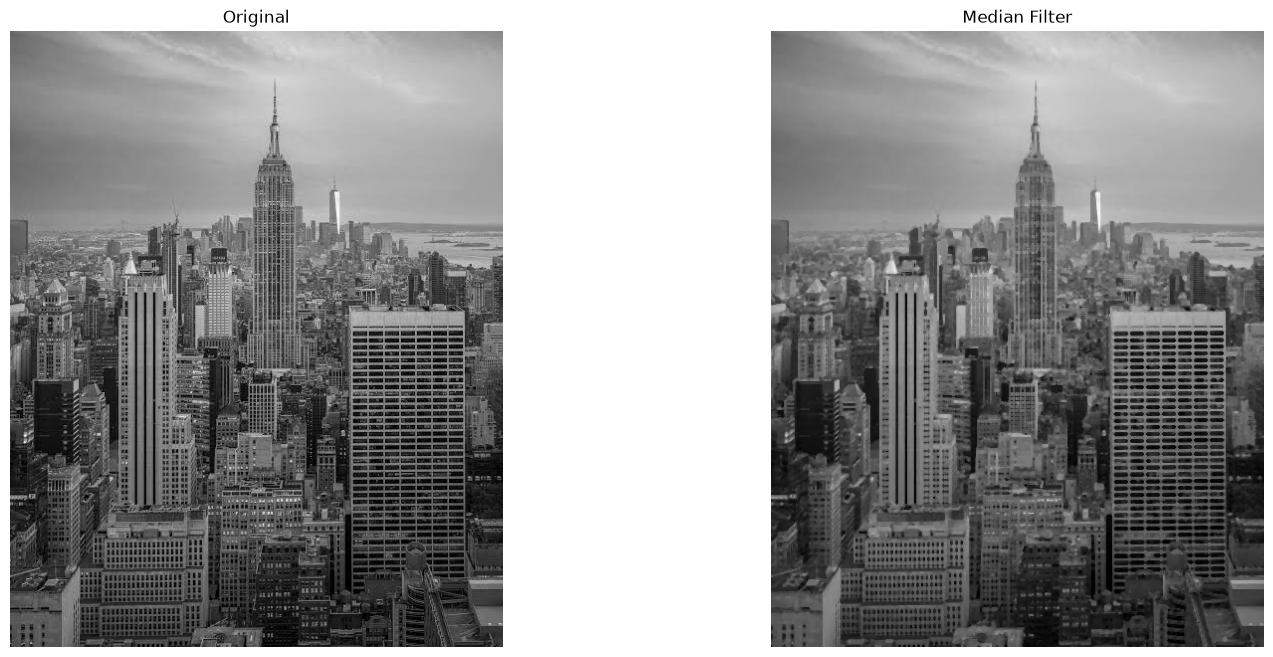

In [6]:
kernel_size = 3
pad = kernel_size // 2

padded = np.pad(gray_img, pad, mode="edge")
windows = np.lib.stride_tricks.sliding_window_view(padded, (kernel_size, kernel_size))

# Median of each window
img_median = np.median(windows, axis=(2, 3)).astype(np.uint8)

plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
show_plt("Original", gray_img)
plt.subplot(1,2,2)
show_plt("Median Filter", img_median)

### *Gaussian Filter*

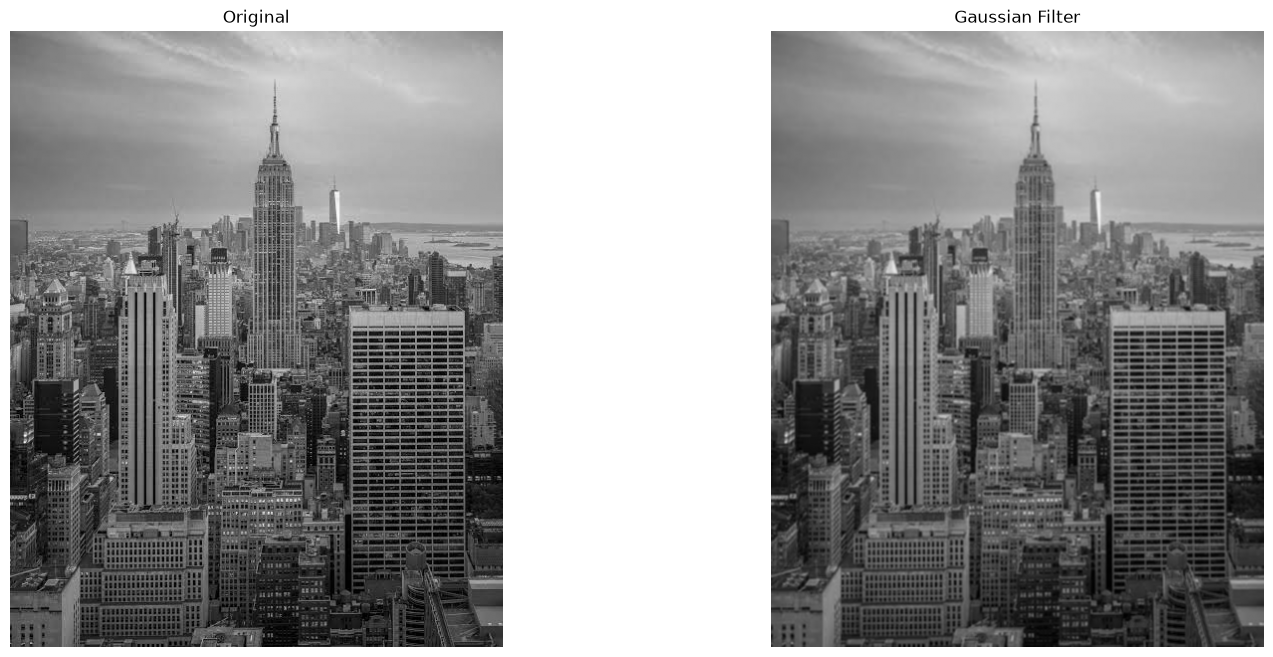

In [ ]:
def gaussian_kernel_2d(kernel_size, sigma):
    # G(x, y) = exp(-(x^2 + y^2) / (2 * sigma^2)), normalized so that the weights sum to 1
    ax = np.arange(kernel_size) - kernel_size // 2
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return (kernel / kernel.sum()).astype(np.float32)

# Kernel
kernel_size = 3
sigma = 1
gaussian_kernel = gaussian_kernel_2d(kernel_size, sigma)

# Convolution
img_gaussian = cv2.filter2D(gray_img, -1, gaussian_kernel)

plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
show_plt("Original", gray_img)
plt.subplot(1,2,2)
show_plt("Gaussian Filter", img_gaussian)

## **High-Pass Filters**

In [8]:
blurred_image = cv2.filter2D(gray_img, -1, gaussian_kernel)

### *Sobel Filter*

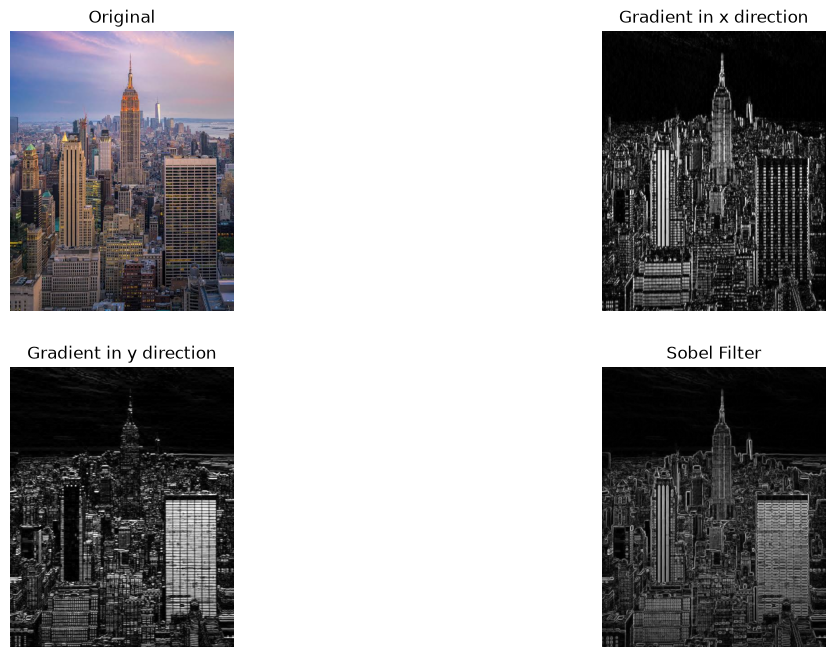

In [9]:
# Kernel
Hx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

Hy = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

# Convolution
horizontal = cv2.filter2D(blurred_image, cv2.CV_32F, Hx)
vertical = cv2.filter2D(blurred_image, cv2.CV_32F, Hy)

# Gradient magnitude
H = np.sqrt(horizontal**2 + vertical**2)

# Normalize to range 0-255
horizontal = cv2.convertScaleAbs(horizontal)
vertical = cv2.convertScaleAbs(vertical)
H = np.uint8(255 * H / np.max(H))

plt.figure(figsize=(14,8))
plt.subplot(2,2,1)
show_plt("Original", img)

plt.subplot(2,2,2)
show_plt("Gradient in x direction", horizontal)

plt.subplot(2,2,3)
show_plt("Gradient in y direction", vertical)

plt.subplot(2,2,4)
show_plt("Sobel Filter", H)

### *Prewitt Filter*

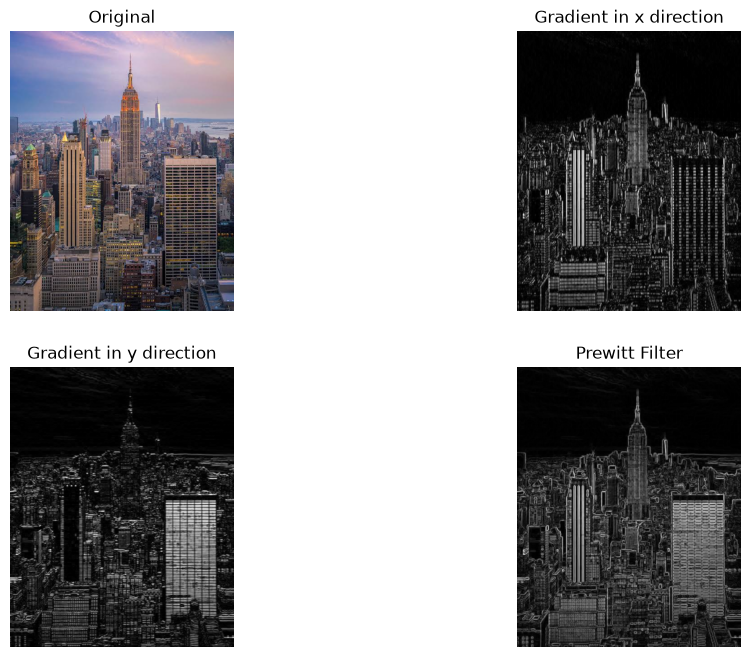

In [10]:
# Kernel
Hx = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
], dtype=np.float32)

Hy = np.array([
    [-1, -1, -1],
    [0 , 0 , 0],
    [1 , 1 , 1]
], dtype=np.float32)

# Convolution
horizontal = cv2.filter2D(blurred_image, cv2.CV_32F, Hx)
vertical = cv2.filter2D(blurred_image, cv2.CV_32F, Hy)

# Gradient magnitude
H = np.sqrt(horizontal**2 + vertical**2)

# Normalize to range 0-255
horizontal = cv2.convertScaleAbs(horizontal)
vertical = cv2.convertScaleAbs(vertical)
H = np.uint8(255 * H / np.max(H))

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
show_plt("Original", img)

plt.subplot(2,2,2)
show_plt("Gradient in x direction", horizontal)

plt.subplot(2,2,3)
show_plt("Gradient in y direction", vertical)

plt.subplot(2,2,4)
show_plt("Prewitt Filter", H)

### *Laplacian Filter*

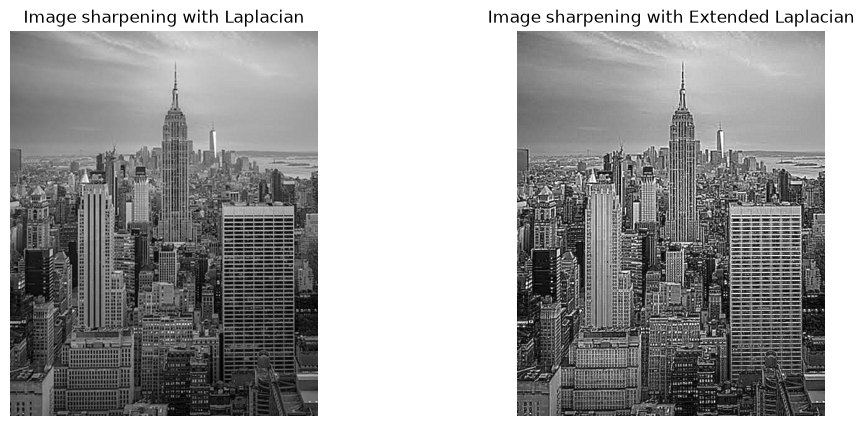

In [11]:
kernel_5 = np.array([
    [0, -1,  0],
    [-1, 5, -1],
    [0, -1,  0]
], dtype=np.float32)

kernel_9 = np.array([
    [-1, -1, -1],
    [-1,  9, -1],
    [-1, -1, -1]
], dtype=np.float32)

H5 = cv2.filter2D(blurred_image, cv2.CV_32F, kernel_5)
H9 = cv2.filter2D(blurred_image, cv2.CV_32F, kernel_9)

# Normalize to range 0-255
H5= cv2.convertScaleAbs(H5)
H9= cv2.convertScaleAbs(H9)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
show_plt("Image sharpening with Laplacian", H5)
plt.subplot(1,2,2)
show_plt("Image sharpening with Extended Laplacian", H9)
plt.show()
